# ML MODEL BINARY CLASSIFICATION MODEL

In [14]:
"""
1.2a ML Model — Binary Classification (Rise vs Fall)
=====================================================
Predicts whether tomorrow's price will rise or fall.
"""

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
)
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_auc_score
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# ── Paths ──────────────────────────────────────────────────────────
PROCESSED_DIR = "../data/processed"
MODELS_DIR = "../models"
os.makedirs(MODELS_DIR, exist_ok=True)

# ── Features ───────────────────────────────────────────────────────
FEATURE_COLS = [
    # Original
    "Returns", "SMA_5", "SMA_20", "Volatility_5", "Volatility_20",
    "Volume_Change", "RSI_14", "Price_Range",
    # New
    "MACD", "MACD_Signal", "MACD_Hist",
    "BB_Width", "BB_Position",
    "Momentum_10", "Momentum_20",
    "ATR_Ratio",
    "Return_Lag1", "Return_Lag2", "Return_Lag3", "Return_Lag5",
    "Volume_Ratio",
    "DayOfWeek",
    "Dist_SMA_5", "Dist_SMA_20",
]

# ── Target ─────────────────────────────────────────────────────────
TARGET = "Target_Binary"
CLASS_NAMES = ["Fall", "Rise"]
MODEL_SUFFIX = "binary"

TICKERS = ["AMZN", "AAPL", "MSFT", "GOOG", "TSLA"]

print("✓ Binary Classification Setup Complete")
print(f"  Target: {TARGET}")
print(f"  Classes: {CLASS_NAMES}")

✓ Binary Classification Setup Complete
  Target: Target_Binary
  Classes: ['Fall', 'Rise']


LOAD DATA

In [15]:
def load_data(ticker: str) -> tuple:
    """Load data for binary classification."""
    
    path = f"{PROCESSED_DIR}/{ticker.lower()}_processed.csv"
    df = pd.read_csv(path, parse_dates=["Date"])
    df = df.sort_values("Date").reset_index(drop=True)
    df = df.dropna(subset=FEATURE_COLS + [TARGET])
    
    X = df[FEATURE_COLS]
    y = df[TARGET].astype(int)
    
    # Time-based split (70/30)
    split_idx = int(len(df) * 0.7)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
    
    print(f"Loaded {ticker}: {len(df)} rows")
    print(f"  Train: {len(X_train)} | Test: {len(X_test)}")
    print(f"  Class balance: {dict(y_train.value_counts().sort_index())}")
    
    return X_train, X_test, y_train, y_test

# Test
X_train, X_test, y_train, y_test = load_data("AMZN")

Loaded AMZN: 1217 rows
  Train: 851 | Test: 366
  Class balance: {0: np.int64(415), 1: np.int64(436)}


DEFINE MODELS

In [16]:
def get_models() -> dict:
    """
    Models optimized for BINARY classification.
    
    Notes:
    - Logistic Regression often works well for binary
    - Using class_weight='balanced' helps with imbalanced data
    - Binary uses 'roc_auc' as main metric
    """
    
    return {
        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                solver="lbfgs",
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            ))
        ]),
        
        "Random Forest": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", RandomForestClassifier(
                n_estimators=200,          # More trees for binary
                max_depth=8,
                min_samples_split=10,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            ))
        ]),
        
        "Gradient Boosting": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", GradientBoostingClassifier(
                n_estimators=150,
                max_depth=4,               # Shallower for binary
                learning_rate=0.1,
                subsample=0.8,
                random_state=42
            ))
        ]),
        
        "XGBoost": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", XGBClassifier(
                n_estimators=150,
                max_depth=5,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                scale_pos_weight=1,        # Adjust if imbalanced
                random_state=42,
                use_label_encoder=False,
                eval_metric="logloss",     # Binary log loss
                verbosity=0
            ))
        ]),
    }

print("Binary Models:", list(get_models().keys()))

Binary Models: ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'XGBoost']


COMPARE MODELS

In [17]:
def compare_models(X_train, X_test, y_train, y_test) -> tuple:
    """Train and evaluate all models for binary classification."""
    
    models = get_models()
    results = []
    trained_models = {}
    
    print("Training Binary Models...")
    print("-" * 65)
    
    for name, pipeline in models.items():
        pipeline.fit(X_train, y_train)
        trained_models[name] = pipeline
        
        y_pred = pipeline.predict(X_test)
        y_proba = pipeline.predict_proba(X_test)[:, 1]  # Probability of class 1
        
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_proba)
        
        results.append({
            "Model": name,
            "Accuracy": round(acc, 4),
            "F1 Score": round(f1, 4),
            "AUC-ROC": round(auc, 4),
        })
        
        print(f"{name:25s} | Acc: {acc:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")
    
    print("-" * 65)
    
    comparison_df = pd.DataFrame(results).sort_values("AUC-ROC", ascending=False)
    return comparison_df, trained_models

comparison, trained_models = compare_models(X_train, X_test, y_train, y_test)
comparison

Training Binary Models...
-----------------------------------------------------------------
Logistic Regression       | Acc: 0.4809 | F1: 0.3667 | AUC: 0.5238
Random Forest             | Acc: 0.4809 | F1: 0.3709 | AUC: 0.5001
Gradient Boosting         | Acc: 0.5355 | F1: 0.4688 | AUC: 0.5248
XGBoost                   | Acc: 0.5301 | F1: 0.4911 | AUC: 0.5072
-----------------------------------------------------------------


,Model,Accuracy,F1 Score,AUC-ROC
2,Gradient Boosting,0.5355,0.4688,0.5248
0,Logistic Regression,0.4809,0.3667,0.5238
3,XGBoost,0.5301,0.4911,0.5072
1,Random Forest,0.4809,0.3709,0.5001


VISUALIZE

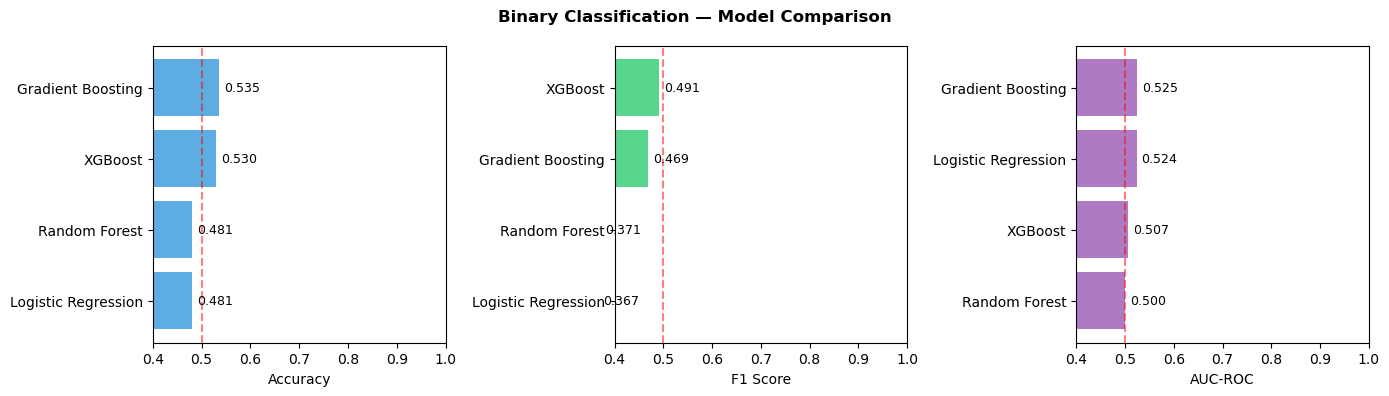

In [18]:
def plot_comparison(comparison_df):
    """Bar chart comparing models."""
    
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    
    for ax, metric, color in zip(axes, ["Accuracy", "F1 Score", "AUC-ROC"], 
                                  ["#3498db", "#2ecc71", "#9b59b6"]):
        data = comparison_df.sort_values(metric, ascending=True)
        ax.barh(data["Model"], data[metric], color=color, alpha=0.8)
        ax.set_xlabel(metric)
        ax.set_xlim(0.4, 1.0)
        ax.axvline(x=0.5, color="red", linestyle="--", alpha=0.5)
        
        for i, v in enumerate(data[metric]):
            ax.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=9)
    
    plt.suptitle("Binary Classification — Model Comparison", fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{MODELS_DIR}/comparison_binary.png", dpi=150)
    plt.show()

plot_comparison(comparison)

CONFUSION MATRIX

Best Model: Gradient Boosting



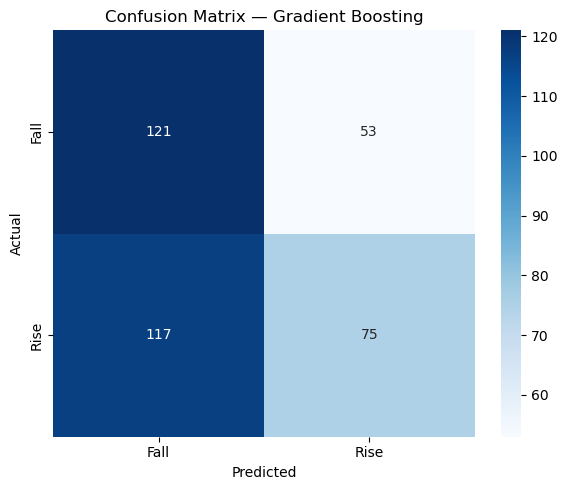

              precision    recall  f1-score   support

        Fall       0.51      0.70      0.59       174
        Rise       0.59      0.39      0.47       192

    accuracy                           0.54       366
   macro avg       0.55      0.54      0.53       366
weighted avg       0.55      0.54      0.53       366



In [19]:
def plot_confusion_matrix(y_test, y_pred, model_name):
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f"Confusion Matrix — {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()
    
    print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

best_name = comparison.iloc[0]["Model"]
best_model = trained_models[best_name]
y_pred = best_model.predict(X_test)

print(f"Best Model: {best_name}\n")
plot_confusion_matrix(y_test, y_pred, best_name)

HYPERPARAMETER TUNING

In [20]:
def tune_model(model_name: str, X_train, y_train):
    """Tune hyperparameters for binary classification."""
    
    # Parameter grids optimized for binary
    param_grids = {
        "Logistic Regression": {
            "clf__C": [0.001, 0.01, 0.1, 1, 10],
            "clf__penalty": ["l2"],
        },
        "Random Forest": {
            "clf__n_estimators": [100, 200, 300],
            "clf__max_depth": [5, 8, 12],
            "clf__min_samples_split": [5, 10],
        },
        "Gradient Boosting": {
            "clf__n_estimators": [100, 150, 200],
            "clf__max_depth": [3, 4, 5],
            "clf__learning_rate": [0.05, 0.1, 0.15],
        },
        "XGBoost": {
            "clf__n_estimators": [100, 200],
            "clf__max_depth": [4, 5, 6],
            "clf__learning_rate": [0.05, 0.1],
            "clf__subsample": [0.7, 0.8],
        },
    }
    
    if model_name not in param_grids:
        return None, None, None
    
    pipeline = get_models()[model_name]
    param_grid = param_grids[model_name]
    
    print(f"Tuning {model_name}...")
    
    grid = GridSearchCV(
        pipeline,
        param_grid,
        cv=TimeSeriesSplit(n_splits=5),
        scoring="roc_auc",  # Binary uses AUC
        n_jobs=-1,
        verbose=0
    )
    
    grid.fit(X_train, y_train)
    
    print(f"  Best params: {grid.best_params_}")
    print(f"  Best CV AUC: {grid.best_score_:.4f}\n")
    
    return grid.best_estimator_, grid.best_params_, grid.best_score_

# Tune top 2 models
top_2 = comparison.head(2)["Model"].tolist()
tuned_models = {}

for name in top_2:
    best_pipe, best_params, best_score = tune_model(name, X_train, y_train)
    if best_pipe:
        tuned_models[name] = {
            "pipeline": best_pipe,
            "params": best_params,
            "cv_score": best_score
        }

Tuning Gradient Boosting...
  Best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 5, 'clf__n_estimators': 100}
  Best CV AUC: 0.4959

Tuning Logistic Regression...
  Best params: {'clf__C': 0.01, 'clf__penalty': 'l2'}
  Best CV AUC: 0.5355



ENSEMBLE

In [21]:
def create_ensemble(X_train, y_train, X_test, y_test):
    """Create ensemble for binary classification."""
    
    ensemble = VotingClassifier(
        estimators=[
            ("lr", Pipeline([
                ("scaler", StandardScaler()),
                ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
            ])),
            ("rf", Pipeline([
                ("scaler", StandardScaler()),
                ("clf", RandomForestClassifier(n_estimators=200, max_depth=8, 
                                               class_weight="balanced", random_state=42))
            ])),
            ("gb", Pipeline([
                ("scaler", StandardScaler()),
                ("clf", GradientBoostingClassifier(n_estimators=150, max_depth=4, random_state=42))
            ])),
            ("xgb", Pipeline([
                ("scaler", StandardScaler()),
                ("clf", XGBClassifier(n_estimators=150, max_depth=5, random_state=42,
                                      use_label_encoder=False, eval_metric="logloss", verbosity=0))
            ])),
        ],
        voting="soft",
        n_jobs=-1
    )
    
    ensemble.fit(X_train, y_train)
    
    y_pred = ensemble.predict(X_test)
    y_proba = ensemble.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    
    print(f"Ensemble: Acc={acc:.4f}, F1={f1:.4f}, AUC={auc:.4f}")
    
    return ensemble, {"Accuracy": acc, "F1": f1, "AUC": auc}

ensemble, ensemble_metrics = create_ensemble(X_train, y_train, X_test, y_test)

Ensemble: Acc=0.5109, F1=0.4458, AUC=0.5145


SELECT BEST AND EXPORT

In [22]:
def select_and_export(ticker, trained_models, tuned_models, ensemble, ensemble_metrics, X_test, y_test):
    """Select best binary model and export."""
    
    print(f"\n{'='*50}")
    print(f"FINAL SELECTION — {ticker} (Binary)")
    print(f"{'='*50}")
    
    candidates = []
    
    # Base models
    for name, pipeline in trained_models.items():
        y_proba = pipeline.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
        candidates.append({"name": name, "pipeline": pipeline, "auc": auc, "type": "Base"})
    
    # Tuned models
    for name, data in tuned_models.items():
        y_proba = data["pipeline"].predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
        candidates.append({"name": f"{name} (Tuned)", "pipeline": data["pipeline"], "auc": auc, "type": "Tuned"})
    
    # Ensemble
    candidates.append({"name": "Ensemble", "pipeline": ensemble, "auc": ensemble_metrics["AUC"], "type": "Ensemble"})
    
    # Sort by AUC
    candidates.sort(key=lambda x: x["auc"], reverse=True)
    
    print("\nRanking (by AUC-ROC):")
    for i, c in enumerate(candidates, 1):
        marker = "👑" if i == 1 else "  "
        print(f"{marker} {i}. {c['name']:30s} AUC={c['auc']:.4f}")
    
    # Export best
    best = candidates[0]
    
    model_path = f"{MODELS_DIR}/model_{ticker}_{MODEL_SUFFIX}.joblib"
    features_path = f"{MODELS_DIR}/features_{ticker}_{MODEL_SUFFIX}.txt"
    
    joblib.dump(best["pipeline"], model_path)
    with open(features_path, "w") as f:
        f.write("\n".join(FEATURE_COLS))
    
    print(f"\n✓ Exported: {model_path}")
    
    return best

best = select_and_export("AMZN", trained_models, tuned_models, ensemble, ensemble_metrics, X_test, y_test)


FINAL SELECTION — AMZN (Binary)

Ranking (by AUC-ROC):
👑 1. Logistic Regression (Tuned)    AUC=0.5314
   2. Gradient Boosting              AUC=0.5248
   3. Logistic Regression            AUC=0.5238
   4. Ensemble                       AUC=0.5145
   5. XGBoost                        AUC=0.5072
   6. Gradient Boosting (Tuned)      AUC=0.5032
   7. Random Forest                  AUC=0.5001

✓ Exported: ../models/model_AMZN_binary.joblib


RUN FOR ALL TICKERS

In [23]:
def process_all_tickers(tickers: list) -> pd.DataFrame:
    """Train binary models for all tickers."""
    
    summary = []
    
    for ticker in tickers:
        print(f"\n{'#'*50}")
        print(f"# {ticker} — Binary Classification")
        print(f"{'#'*50}")
        
        try:
            X_tr, X_te, y_tr, y_te = load_data(ticker)
            comp, trained = compare_models(X_tr, X_te, y_tr, y_te)
            
            top_2 = comp.head(2)["Model"].tolist()
            tuned = {}
            for name in top_2:
                pipe, params, score = tune_model(name, X_tr, y_tr)
                if pipe:
                    tuned[name] = {"pipeline": pipe, "params": params, "cv_score": score}
            
            ens, ens_m = create_ensemble(X_tr, y_tr, X_te, y_te)
            best = select_and_export(ticker, trained, tuned, ens, ens_m, X_te, y_te)
            
            summary.append({
                "Ticker": ticker,
                "Best Model": best["name"],
                "AUC-ROC": round(best["auc"], 4)
            })
            
        except Exception as e:
            print(f"ERROR: {e}")
            summary.append({"Ticker": ticker, "Best Model": "ERROR", "AUC-ROC": np.nan})
    
    return pd.DataFrame(summary)

final_summary = process_all_tickers(TICKERS)
final_summary


##################################################
# AMZN — Binary Classification
##################################################
Loaded AMZN: 1217 rows
  Train: 851 | Test: 366
  Class balance: {0: np.int64(415), 1: np.int64(436)}
Training Binary Models...
-----------------------------------------------------------------
Logistic Regression       | Acc: 0.4809 | F1: 0.3667 | AUC: 0.5238
Random Forest             | Acc: 0.4809 | F1: 0.3709 | AUC: 0.5001
Gradient Boosting         | Acc: 0.5355 | F1: 0.4688 | AUC: 0.5248
XGBoost                   | Acc: 0.5301 | F1: 0.4911 | AUC: 0.5072
-----------------------------------------------------------------
Tuning Gradient Boosting...
  Best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 5, 'clf__n_estimators': 100}
  Best CV AUC: 0.4959

Tuning Logistic Regression...
  Best params: {'clf__C': 0.01, 'clf__penalty': 'l2'}
  Best CV AUC: 0.5355

Ensemble: Acc=0.5109, F1=0.4458, AUC=0.5145

FINAL SELECTION — AMZN (Binary)

Ranking (by 

,Ticker,Best Model,AUC-ROC
0,AMZN,Logistic Regression (Tuned),0.5314
1,AAPL,Random Forest (Tuned),0.4768
2,MSFT,Ensemble,0.5617
3,GOOG,Logistic Regression (Tuned),0.5658
4,TSLA,Logistic Regression (Tuned),0.5841


VERIFY

In [24]:
print("Binary Models Exported:")
print("-" * 40)
for ticker in TICKERS:
    model_ok = os.path.exists(f"{MODELS_DIR}/model_{ticker}_binary.joblib")
    feat_ok = os.path.exists(f"{MODELS_DIR}/features_{ticker}_binary.txt")
    status = "✓" if (model_ok and feat_ok) else "✗"
    print(f"{status} {ticker}_binary")

Binary Models Exported:
----------------------------------------
✓ AMZN_binary
✓ AAPL_binary
✓ MSFT_binary
✓ GOOG_binary
✓ TSLA_binary
